<a href="https://colab.research.google.com/github/milkmaN4123/Data_bases_Cw_northstar/blob/clean/Python_data_cleanse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Load packages for data cleanse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import pandas.api.types as pdt
import os
from google.colab import drive
from pprint import pprint
import json

In [ ]:
drive.mount('drive')

Mounted at drive


In [ ]:
#Import files from github
deliveries_data = "https://raw.githubusercontent.com/milkmaN4123/Data_bases_Cw_northstar/d1de0d28e870472ce0218f2e07b802e85d25708d/deliveries.csv"
complaints_data = "https://raw.githubusercontent.com/milkmaN4123/Data_bases_Cw_northstar/d1de0d28e870472ce0218f2e07b802e85d25708d/complaints.csv"
customers_data = "https://raw.githubusercontent.com/milkmaN4123/Data_bases_Cw_northstar/d1de0d28e870472ce0218f2e07b802e85d25708d/customers.csv"
drivers_data = "https://raw.githubusercontent.com/milkmaN4123/Data_bases_Cw_northstar/d1de0d28e870472ce0218f2e07b802e85d25708d/drivers.csv"
hubs_data = "https://raw.githubusercontent.com/milkmaN4123/Data_bases_Cw_northstar/d1de0d28e870472ce0218f2e07b802e85d25708d/hubs.csv"
orders_data = "https://raw.githubusercontent.com/milkmaN4123/Data_bases_Cw_northstar/d1de0d28e870472ce0218f2e07b802e85d25708d/orders.csv"
incidents_data = "https://raw.githubusercontent.com/milkmaN4123/Data_bases_Cw_northstar/d1de0d28e870472ce0218f2e07b802e85d25708d/incidents.csv"
vehicles_data = "https://raw.githubusercontent.com/milkmaN4123/Data_bases_Cw_northstar/d1de0d28e870472ce0218f2e07b802e85d25708d/vehicles.csv"
app_data = "https://raw.githubusercontent.com/milkmaN4123/Data_bases_Cw_northstar/d1de0d28e870472ce0218f2e07b802e85d25708d/app_events.csv"


In [ ]:
# create dataframes of the data
# helps with the Extraction, transformation, and loading of the data
#print the shape of the data
#checks to see if imported correctly

df_deliveries = pd.read_csv(deliveries_data)
print(df_deliveries.shape)

df_complaints = pd.read_csv(complaints_data)
print(df_complaints.shape)

df_customers = pd.read_csv(customers_data)
print(df_customers.shape)

df_drivers = pd.read_csv(drivers_data)
print(df_drivers.shape)

df_hubs = pd.read_csv(hubs_data)
print(df_hubs.shape)

df_orders = pd.read_csv(orders_data)
print(df_orders.shape)

df_incidents = pd.read_csv(incidents_data)
print(df_incidents.shape)

df_vehicles = pd.read_csv(vehicles_data)
print(df_vehicles.shape)

df_app = pd.read_csv(app_data)
print(df_app.shape)

(950, 13)
(320, 10)
(650, 9)
(170, 8)
(8, 5)
(1250, 11)
(280, 7)
(120, 8)
(640, 10)


In [ ]:
# This is to clean the data in the delivery file
# including correcting data types and checking missing values
# to ensure data consistency values have been converted to lower case and empty spaces have been trimmed


# string data type columns
df_deliveries["delivery_id"] = df_deliveries["delivery_id"].astype("string")
df_deliveries["order_id"] = df_deliveries["order_id"].astype("string")
df_deliveries["driver_id"] = df_deliveries["driver_id"].astype("string")
df_deliveries["vehicle_id"] = df_deliveries["vehicle_id"].astype("string")
df_deliveries["hub_id"] = df_deliveries["hub_id"].astype("string")
df_deliveries["delivery_status"] = df_deliveries["delivery_status"].astype("string")


#Date time data types
df_deliveries["dispatch_time"] = pd.to_datetime(df_deliveries["dispatch_time"], errors="coerce")
df_deliveries["delivery_completed_at"] = pd.to_datetime(df_deliveries["delivery_completed_at"], errors="coerce")
df_deliveries["delivery_duration_hours"] = (df_deliveries["delivery_completed_at"] - df_deliveries["dispatch_time"]).dt.total_seconds() / 3600

df_deliveries["delivery_duration_hours"] = df_deliveries["delivery_duration_hours"].round(2)

# numeric data types i.e integer, float, and boolean
df_deliveries["route_distance_km"] = pd.to_numeric(df_deliveries["route_distance_km"], errors="coerce")
df_deliveries["manual_route_override_count"] = pd.to_numeric(df_deliveries["manual_route_override_count"], errors="coerce").astype("Int64")
df_deliveries["proof_of_completion_missing"] = pd.to_numeric(df_deliveries["proof_of_completion_missing"], errors="coerce").astype("bool")
df_deliveries["customer_rating_post_delivery"] = pd.to_numeric(df_deliveries["customer_rating_post_delivery"], errors="coerce")
df_deliveries["missing_proof"] = df_deliveries["proof_of_completion_missing"].map({True: 1,False: 0})
df_deliveries["fuel_or_charge_cost"] = pd.to_numeric(df_deliveries["fuel_or_charge_cost"], errors="coerce")
#df_deliveries["days_between"] = pd.to_numeric((df_deliveries["delivery_completed_at"] - df_deliveries["dispatch date"]).dt.days).astype("Int64")

# make values consistent (lower case and trim empty space)
df_deliveries = df_deliveries.apply(lambda col: col.str.strip().str.lower() if pdt.is_string_dtype(col) else col)

df_deliveries.isna().sum()
# Customer rating has 14 values missing pre drop
# delivery completed at has 19 values missing pre drop

# remove missing
df_deliveries=df_deliveries.dropna()

#check missing after removal
df_deliveries.isna().sum()

,0
delivery_id,0
order_id,0
driver_id,0
vehicle_id,0
hub_id,0
dispatch_time,0
delivery_completed_at,0
delivery_status,0
route_distance_km,0
manual_route_override_count,0


In [ ]:
print(df_deliveries.dtypes)
df_deliveries.head()


delivery_id                      string[python]
order_id                         string[python]
driver_id                        string[python]
vehicle_id                       string[python]
hub_id                           string[python]
dispatch_time                    datetime64[ns]
delivery_completed_at            datetime64[ns]
delivery_status                  string[python]
route_distance_km                       float64
manual_route_override_count               Int64
proof_of_completion_missing                bool
customer_rating_post_delivery           float64
fuel_or_charge_cost                     float64
missing_proof                             int64
delivery_duration_hours                 float64
dtype: object


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,missing_proof,delivery_duration_hours
0,dl00001,o00938,d004,v056,h05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,failed,17.26,1,False,3.07,12.05,0,22.15
1,dl00002,o00004,d138,v007,h02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,ontime,10.34,1,False,5.00,13.41,0,-1.10
2,dl00003,o00639,d006,v049,h02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,ontime,7.92,0,False,4.98,8.51,0,1.11
3,dl00004,o00313,d116,v055,h02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,delayed,16.42,0,False,4.18,13.62,0,23.99
4,dl00005,o00844,d108,v034,h01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,ontime,14.52,1,False,4.18,9.22,0,4.04


In [ ]:
# this is to clean the data in Complaints file
# including correcting data types and chekcing missing values
# to ensure data consistency values have been converted to lower case and empty spaces have been trimmed


# change compensation_amount to float
df_complaints["compensation_amount"] = pd.to_numeric(df_complaints["compensation_amount"],errors="coerce")

# convert created_at to datetime
df_complaints["created_at"] = pd.to_datetime(df_complaints["created_at"],errors="coerce").dt.normalize()


# converts the following columns into string datatype
df_complaints["complaint_type"] = df_complaints["complaint_type"].astype("string")

df_complaints["channel"] = df_complaints["channel"].astype("string")

df_complaints["severity"] = df_complaints["severity"].astype("string")

df_complaints["status"] = df_complaints["status"].astype("string")

df_complaints["order_id"] = df_complaints["order_id"].astype("string")

df_complaints["customer_id"] = df_complaints["customer_id"].astype("string")

df_complaints["complaint_id"] = df_complaints["complaint_id"].astype("string")

# remove capital letters and empty spaces from values within data
df_complaints = df_complaints.apply(lambda col: col.str.strip().str.lower() if pdt.is_string_dtype(col) else col)

# remove missing
df_complaints=df_complaints.dropna()


#compensation amount has 16 missing values before removal
#check missing values in complaints
df_complaints.isna().sum()


,0
complaint_id,0
customer_id,0
order_id,0
complaint_type,0
channel,0
severity,0
created_at,0
status,0
resolution_days,0
compensation_amount,0


In [ ]:
# check data types of complaints file
# check cleanse has worked
print(df_complaints.dtypes)
df_complaints.head()


complaint_id           string[python]
customer_id            string[python]
order_id               string[python]
complaint_type         string[python]
channel                string[python]
severity               string[python]
created_at             datetime64[ns]
status                 string[python]
resolution_days                 int64
compensation_amount           float64
dtype: object


,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
0,cp0001,c0464,o00814,appissue,app,high,2025-03-30,open,11,23.99
1,cp0002,c0056,o00628,missedpickup,phone,medium,2024-11-07,open,4,21.64
2,cp0003,c0469,o00384,delay,chatbot,high,2024-01-02,open,16,26.41
3,cp0004,c0631,o00406,delay,app,medium,2025-01-14,awaitingcustomer,7,23.44
4,cp0005,c0535,o00154,delay,email,medium,2024-08-31,resolved,1,16.18


In [ ]:
# this is to clean the data in Customers file
# including correcting data types and checking missing values
# to ensure data consistency values have been converted to lower case and empty spaces have been trimmed
# create derived columns to use for analysis



# String data type columns
df_customers["customer_id"] = df_customers["customer_id"].astype("string")
df_customers["age"] = pd.to_numeric(df_customers["age"], errors="coerce").astype("Int64")
df_customers["home_zone"] = df_customers["home_zone"].astype("string")
df_customers["customer_type"] = df_customers["customer_type"].astype("string")
df_customers["preferred_channel"] = df_customers["preferred_channel"].astype("string")
df_customers["account_status"] = df_customers["account_status"].astype("string")


# Date time columns
df_customers["signup_date"] = pd.to_datetime(df_customers["signup_date"],errors="coerce").dt.normalize()


# numeric columns
df_customers["loyalty_score"] = pd.to_numeric(df_customers["loyalty_score"], errors="coerce")
df_customers["app_engagement_score"] = pd.to_numeric(df_customers["app_engagement_score"], errors="coerce")



df_customers.isna().sum()

# remove capital letters and empty spaces from values within data
df_customers = df_customers.apply(lambda col: col.str.strip().str.lower() if pdt.is_string_dtype(col) else col)


# to align values to improve consistency
df_customers["home_zone"] = df_customers["home_zone"].replace("ctr", "central")

# remove missing
# prefferred channel has 13 missing before removal
df_customers=df_customers.dropna()

#check missing after removal
df_customers.isna().sum()



,0
customer_id,0
age,0
home_zone,0
customer_type,0
signup_date,0
loyalty_score,0
app_engagement_score,0
preferred_channel,0
account_status,0


In [ ]:
# check data types of Customers file
# check cleanse has worked
print(df_customers.dtypes)
df_customers.head()

customer_id             string[python]
age                              Int64
home_zone               string[python]
customer_type           string[python]
signup_date             datetime64[ns]
loyalty_score                  float64
app_engagement_score           float64
preferred_channel       string[python]
account_status          string[python]
dtype: object


,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,c0001,26,north,sme,2024-11-27,44.9,69.2,app,active
1,c0002,61,airport,consumer,2025-10-28,55.4,66.6,app,active
3,c0004,75,central,consumer,2025-08-19,32.5,33.0,app,active
4,c0005,26,riverside,consumer,2025-06-03,55.9,100.0,web,active
5,c0006,41,west,consumer,2024-03-29,39.9,43.3,web,active


In [ ]:
# this is to clean the data in drivers file
# including correcting data types and checking missing values
# to ensure data consistency values have been converted to lower case and empty spaces have been trimmed
# create derived columns to use for analysis

# string data columns
df_drivers["driver_id"] = df_drivers["driver_id"].astype("string")
df_drivers["base_zone"] = df_drivers["base_zone"].astype("string")
df_drivers["employment_type"] = df_drivers["employment_type"].astype("string")
df_drivers["shift_preference"] = df_drivers["shift_preference"].astype("string")

# numeric data columns
df_drivers["years_experience"] = pd.to_numeric(df_drivers["years_experience"], errors="coerce").astype("Int64")
df_drivers["training_score"] = pd.to_numeric(df_drivers["training_score"], errors="coerce")
df_drivers["driver_rating"] = pd.to_numeric(df_drivers["driver_rating"], errors="coerce")
df_drivers["active_flag"] = pd.to_numeric(df_drivers["active_flag"], errors="coerce").astype("boolean")

# make values consistent (lower case and trim empty space)
df_drivers = df_drivers.apply(lambda col: col.str.strip().str.lower() if pdt.is_string_dtype(col) else col)

df_drivers["base_zone"] = df_drivers["base_zone"].replace("ctr", "central")

df_drivers.isna().sum()
# training score has 7 values missing pre drop

# remove missing
df_drivers=df_drivers.dropna()

#check missing after removal
df_drivers.isna().sum()



,0
driver_id,0
base_zone,0
employment_type,0
years_experience,0
training_score,0
driver_rating,0
shift_preference,0
active_flag,0


In [ ]:
# check data types of drivers file
# check cleanse has worked
print(df_drivers.dtypes)
df_drivers.head()

driver_id           string[python]
base_zone           string[python]
employment_type     string[python]
years_experience             Int64
training_score             float64
driver_rating              float64
shift_preference    string[python]
active_flag                boolean
dtype: object


,driver_id,base_zone,employment_type,years_experience,training_score,driver_rating,shift_preference,active_flag
0,d001,airport,fulltime,8,67.8,3.54,morning,True
1,d002,central,fulltime,4,42.4,3.94,evening,True
2,d003,airport,fulltime,11,96.5,5.00,evening,True
3,d004,airport,parttime,13,88.9,4.75,morning,True
4,d005,north,fulltime,3,69.7,4.14,morning,True


In [ ]:
# this is to clean the data in hubs file
# including correcting data types and checking missing values
# to ensure data consistency values have been converted to lower case and empty spaces have been trimmed
# create derived columns to use for analysis


# string data types
df_hubs["hub_id"] = df_hubs["hub_id"].astype("string")
df_hubs["hub_name"] = df_hubs["hub_name"].astype("string")
df_hubs["zone"] = df_hubs["zone"].astype("string")
df_hubs["hub_type"] = df_hubs["hub_type"].astype("string")

# Numeric data types
df_hubs["capacity_score"] = pd.to_numeric(df_hubs["capacity_score"], errors="coerce").astype("Int64")

# # remove capital letters and empty spaces from values within data
df_hubs = df_hubs.apply(lambda col: col.str.strip().str.lower() if pdt.is_string_dtype(col) else col)

# remove missing
df_hubs=df_hubs.dropna()

#check missing after removal
df_hubs.isna().sum()


,0
hub_id,0
hub_name,0
zone,0
hub_type,0
capacity_score,0


In [ ]:
# check data types of hubs file
# check cleanse has worked
print(df_hubs.dtypes)
df_hubs.head()

hub_id            string[python]
hub_name          string[python]
zone              string[python]
hub_type          string[python]
capacity_score             Int64
dtype: object


,hub_id,hub_name,zone,hub_type,capacity_score
0,h01,north exchange,north,dispatch,82
1,h02,south link,south,dispatch,78
2,h03,east dock,east,warehouse,74
3,h04,west gate,west,dispatch,69
4,h05,central core,central,control,88


In [ ]:
# this is to clean the data in orders file
# including correcting data types and checking missing values
# to ensure data consistency values have been converted to lower case and empty spaces have been trimmed
# create derived columns to use for analysis



#string data types
df_orders["order_id"] = df_orders["order_id"].astype("string")
df_orders["customer_id"] = df_orders["customer_id"].astype("string")
df_orders["service_type"] = df_orders["service_type"].astype("string")
df_orders["pickup_zone"] = df_orders["pickup_zone"].astype("string")
df_orders["dropoff_zone"] = df_orders["dropoff_zone"].astype("string")
df_orders["priority_level"] = df_orders["priority_level"].astype("string")
df_orders["booking_channel"] = df_orders["booking_channel"].astype("string")


# date time data type
df_orders["order_created_at"] = pd.to_datetime(df_orders["order_created_at"], errors="coerce").dt.normalize()

# numeric data type
df_orders["promised_window_hours"] = pd.to_numeric(df_orders["promised_window_hours"], errors="coerce").astype("Int64")
df_orders["order_value"] = pd.to_numeric(df_orders["order_value"], errors="coerce")
df_orders["special_handling_flag"] = pd.to_numeric(df_orders["special_handling_flag"], errors="coerce").astype("boolean")


# remove capital letters and empty spaces from values within data
df_orders = df_orders.apply(lambda col: col.str.strip().str.lower() if pdt.is_string_dtype(col) else col)

df_orders["booking_channel"] = df_orders["booking_channel"].replace("api", "app")
df_orders["pickup_zone"] = df_orders["pickup_zone"].replace("ctr", "central")
df_orders["dropoff_zone"] = df_orders["dropoff_zone"].replace("ctr", "central")

df_orders.isna().sum()
# no missing values

# remove missing
df_orders=df_orders.dropna()

#check missing after removal
df_orders.isna().sum()

,0
order_id,0
customer_id,0
service_type,0
order_created_at,0
promised_window_hours,0
pickup_zone,0
dropoff_zone,0
priority_level,0
order_value,0
booking_channel,0


In [ ]:
# check data types of orders file
# check cleanse has worked
print(df_orders.dtypes)
df_orders.head()

order_id                 string[python]
customer_id              string[python]
service_type             string[python]
order_created_at         datetime64[ns]
promised_window_hours             Int64
pickup_zone              string[python]
dropoff_zone             string[python]
priority_level           string[python]
order_value                     float64
booking_channel          string[python]
special_handling_flag           boolean
dtype: object


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,o00001,c0292,passenger,2024-08-20,6,airport,south,medium,126.65,app,False
1,o00002,c0459,passenger,2024-05-14,24,north,airport,low,109.30,app,False
2,o00003,c0161,passenger,2025-09-02,4,west,airport,high,33.50,phone,False
3,o00004,c0520,parcel,2025-01-11,2,riverside,north,medium,10.04,app,True
4,o00005,c0558,retail,2025-02-17,12,riverside,south,low,125.58,phone,False


In [ ]:
# this is to clean the data in incidents file
# including correcting data types and checking missing values
# to ensure data consistency values have been converted to lower case and empty spaces have been trimmed
# create derived columns to use for analysis

# string data type
df_incidents["incident_id"] = df_incidents["incident_id"].astype("string")
df_incidents["delivery_id"] = df_incidents["delivery_id"].astype("string")
df_incidents["incident_type"] = df_incidents["incident_type"].astype("string")
df_incidents["severity"] = df_incidents["severity"].astype("string")
df_incidents["resolution_status"] = df_incidents["resolution_status"].astype("string")

# date time column type


df_incidents["reported_at"] = pd.to_datetime(df_incidents["reported_at"]).dt.normalize()


# numeric data type
df_incidents["resolved_hours"] = pd.to_numeric(df_incidents["resolved_hours"], errors="coerce")


# make values consistent (lower case and trim empty space)
df_incidents = df_incidents.apply(lambda col: col.str.strip().str.lower() if pdt.is_string_dtype(col) else col)

# resolved_hours has 17 missing
df_incidents.isna().sum()

# remove missing
df_incidents=df_incidents.dropna()

#check missing after removal
df_incidents.isna().sum()

,0
incident_id,0
delivery_id,0
incident_type,0
reported_at,0
severity,0
resolution_status,0
resolved_hours,0


In [ ]:
# check data types of incidents file
# check cleanse has worked
print(df_incidents.dtypes)
df_incidents.head()

incident_id          string[python]
delivery_id          string[python]
incident_type        string[python]
reported_at          datetime64[ns]
severity             string[python]
resolution_status    string[python]
resolved_hours              float64
dtype: object


,incident_id,delivery_id,incident_type,reported_at,severity,resolution_status,resolved_hours
0,i0001,dl00221,batteryalert,2024-03-11,medium,escalated,12.3
1,i0002,dl00578,batteryalert,2024-02-21,low,open,9.6
2,i0003,dl00175,temperatureissue,2025-04-17,medium,open,22.0
3,i0004,dl00417,proofmissing,2025-02-09,medium,closed,9.8
4,i0005,dl00897,routedeviation,2025-01-04,low,open,13.0


In [ ]:
# this is to clean the data in vehicles file
# including correcting data types and chekcing missing values
# to ensure data consistency values have been converted to lower case and empty spaces have been trimmed
# create derived columns to use for analysis

#String data type
df_vehicles["vehicle_id"] = df_vehicles["vehicle_id"].astype("string")
df_vehicles["vehicle_type"] = df_vehicles["vehicle_type"].astype("string")
df_vehicles["assigned_zone"] = df_vehicles["assigned_zone"].astype("string")
df_vehicles["maintenance_status"] = df_vehicles["maintenance_status"].astype("string")
df_vehicles["telematics_version"] = df_vehicles["telematics_version"].astype("string")

#date time
df_vehicles["commission_date"] = pd.to_datetime(df_vehicles["commission_date"], errors="coerce").dt.normalize()

#numeric
df_vehicles["battery_health_pct"] = pd.to_numeric(df_vehicles["battery_health_pct"], errors="coerce")
df_vehicles["odometer_km"] = pd.to_numeric(df_vehicles["odometer_km"], errors="coerce").astype("Int64")

# make values consistent (lower case and trim empty space)
df_vehicles = df_vehicles.apply(lambda col: col.str.strip().str.lower() if pdt.is_string_dtype(col) else col)

df_vehicles["assigned_zone"] = df_vehicles["assigned_zone"].replace("ctr", "central")

df_vehicles.isna().sum()
# battery health has 4 missing values

# remove missing
df_vehicles=df_vehicles.dropna()

#check missing after removal
df_vehicles.isna().sum()



,0
vehicle_id,0
vehicle_type,0
assigned_zone,0
commission_date,0
battery_health_pct,0
odometer_km,0
maintenance_status,0
telematics_version,0


In [ ]:
# check data types of vehicles file
# check cleanse has worked
print(df_vehicles.dtypes)
df_vehicles.head()

vehicle_id            string[python]
vehicle_type          string[python]
assigned_zone         string[python]
commission_date       datetime64[ns]
battery_health_pct           float64
odometer_km                    Int64
maintenance_status    string[python]
telematics_version    string[python]
dtype: object


,vehicle_id,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version
0,v001,ev,north,2024-12-28,71.8,56928,active,v2.2
1,v002,ev,airport,2024-04-21,67.9,159368,inrepair,v2.2
2,v003,cargovan,north,2025-11-24,91.7,219359,active,v2.1
4,v005,cargovan,west,2025-11-15,58.6,146638,active,v2.2
5,v006,ev,central,2025-11-22,78.6,141381,active,v2.1


In [ ]:
# this is to clean the data in app file
# including correcting data types and chekcing missing values
# to ensure data consistency values have been converted to lower case and empty spaces have been trimmed
# create derived columns to use for analysis


df_app["event_id"] = df_app["event_id"].astype("string")
df_app["customer_id"] = df_app["customer_id"].astype("string")
df_app["order_id"] = df_app["order_id"].astype("string")
df_app["event_type"] = df_app["event_type"].astype("string")
df_app["session_id"] = df_app["session_id"].astype("string")
df_app["device_type"] = df_app["device_type"].astype("string")
df_app["zone_context"] = df_app["zone_context"].astype("string")

# Standardise values
df_app["zone_context"] = df_app["zone_context"].replace("ctr", "central")

# convert event time to date data type
df_app["event_timestamp"] = pd.to_datetime(
    df_app["event_timestamp"],
    errors="coerce",
    dayfirst=True
)

# Numeric data type
df_app["api_latency_ms"] = pd.to_numeric(df_app["api_latency_ms"], errors="coerce").astype("Int64")

# convert success flag to boolean value
df_app["success_flag"] = (
    df_app["success_flag"]
    .astype("string")
    .str.strip()
    .str.upper()
    .map({"TRUE": True, "FALSE": False})
    .astype("boolean")
)

# Derive success as a numeric column for analysis
df_app["success"] = df_app["success_flag"].map({True: 1, False: 0}).astype("Int64")

# Trim and lowercase column values for data consistency
df_app = df_app.apply(
    lambda col: col.str.strip().str.lower() if pdt.is_string_dtype(col) else col
)

# check before dropping nulls
print("Missing values before drop:")
print(df_app.isna().sum())

# establish primary Key columns that should not have duplicates
critical_cols = [
    "event_id",
    "customer_id",
    "order_id",
    "event_timestamp",
    "event_type",
    "session_id"
]

df_app = df_app.dropna(subset=critical_cols).copy()

print("\nMissing values after dropping critical nulls:")
print(df_app.isna().sum())

# Remove duplicate events if needed
df_app = df_app.drop_duplicates(subset=["event_id"]).copy()

# Sort in time order within each order
df_app = df_app.sort_values(["order_id", "event_timestamp"]).copy()

# Create sequence number within each order
df_app["event_sequence"] = df_app.groupby("order_id").cumcount() + 1

Missing values before drop:
event_id             0
customer_id          0
order_id           144
event_timestamp    381
event_type           0
session_id           0
device_type          0
zone_context         0
api_latency_ms       0
success_flag       640
success            640
dtype: int64

Missing values after dropping critical nulls:
event_id             0
customer_id          0
order_id             0
event_timestamp      0
event_type           0
session_id           0
device_type          0
zone_context         0
api_latency_ms       0
success_flag       209
success            209
dtype: int64


In [ ]:
# this is to tranfrom the data in the app file for NOSQL modelling

app_documents = []

for order_id, group in df_app.groupby("order_id"):
    first_row = group.iloc[0]

    # Build embedded event array for mongodb modelling
    events = []
    for _, row in group.iterrows():
        event_doc = {
            "event_id": row["event_id"],
            "event_timestamp": row["event_timestamp"].to_pydatetime() if pd.notnull(row["event_timestamp"]) else None,
            "event_sequence": int(row["event_sequence"]) if pd.notnull(row["event_sequence"]) else None,
            "event_type": row["event_type"],
            "session_id": row["session_id"],
            "device_type": row["device_type"],
            "zone_context": row["zone_context"],
            "api_latency_ms": int(row["api_latency_ms"]) if pd.notnull(row["api_latency_ms"]) else None,
            "success_flag": bool(row["success_flag"]) if pd.notnull(row["success_flag"]) else None,
            "success": int(row["success"]) if pd.notnull(row["success"]) else None
        }
        events.append(event_doc)

    # Build top-level order document
    doc = {
        "order_id": first_row["order_id"],
        "customer_id": first_row["customer_id"],
        "session_ids": group["session_id"].dropna().unique().tolist(),
        "device_types": group["device_type"].dropna().unique().tolist(),
        "zone_contexts": group["zone_context"].dropna().unique().tolist(),
        "summary": {
            "event_count": int(len(group)),
            "successful_event_count": int(group["success"].fillna(0).sum()),
            "failed_event_count": int(len(group) - group["success"].fillna(0).sum()),
            "avg_api_latency_ms": float(group["api_latency_ms"].dropna().mean()) if group["api_latency_ms"].notna().any() else None,
            "first_event_timestamp": group["event_timestamp"].min().to_pydatetime() if group["event_timestamp"].notna().any() else None,
            "last_event_timestamp": group["event_timestamp"].max().to_pydatetime() if group["event_timestamp"].notna().any() else None
        },
        "events": events
    }

    app_documents.append(doc)


# Preview transformed document
pprint(app_documents[0])

{'customer_id': 'c0112',
 'device_types': ['android'],
 'events': [{'api_latency_ms': 204,
             'device_type': 'android',
             'event_id': 'ae00503',
             'event_sequence': 1,
             'event_timestamp': datetime.datetime(2024, 2, 8, 12, 35),
             'event_type': 'delivery_instruction_update',
             'session_id': 's44209',
             'success': None,
             'success_flag': None,
             'zone_context': 'riverside'}],
 'order_id': 'o00001',
 'session_ids': ['s44209'],
 'summary': {'avg_api_latency_ms': 204.0,
             'event_count': 1,
             'failed_event_count': 1,
             'first_event_timestamp': datetime.datetime(2024, 2, 8, 12, 35),
             'last_event_timestamp': datetime.datetime(2024, 2, 8, 12, 35),
             'successful_event_count': 0},
 'zone_contexts': ['riverside']}


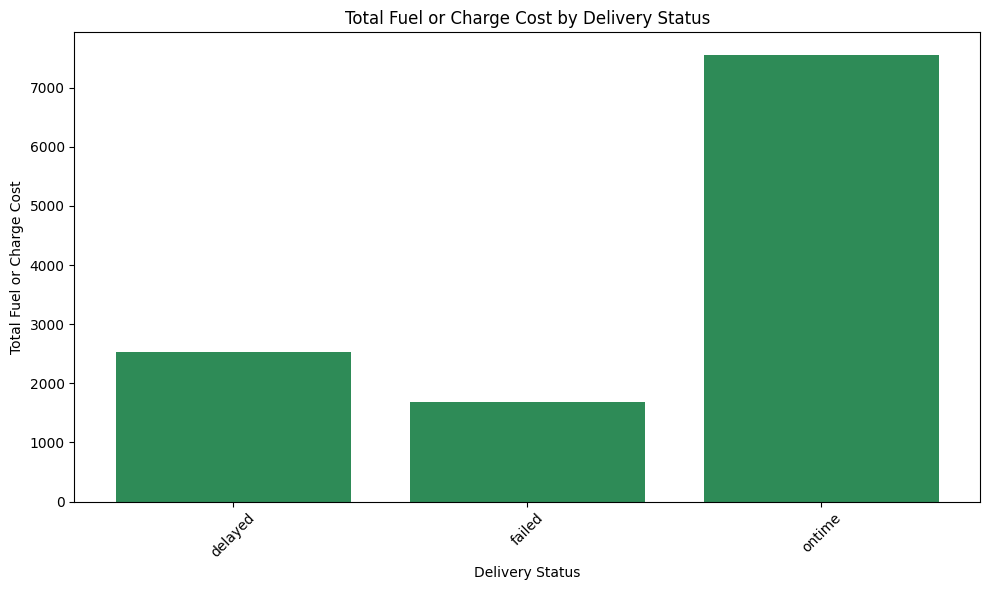

In [ ]:
# graph to show cost of delivery by its status


bar_data = df_deliveries.groupby("delivery_status")["fuel_or_charge_cost"].sum()

plt.figure(figsize=(10, 6))
plt.bar(bar_data.index, bar_data.values, color="seagreen")

plt.title("Total Fuel or Charge Cost by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Total Fuel or Charge Cost")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

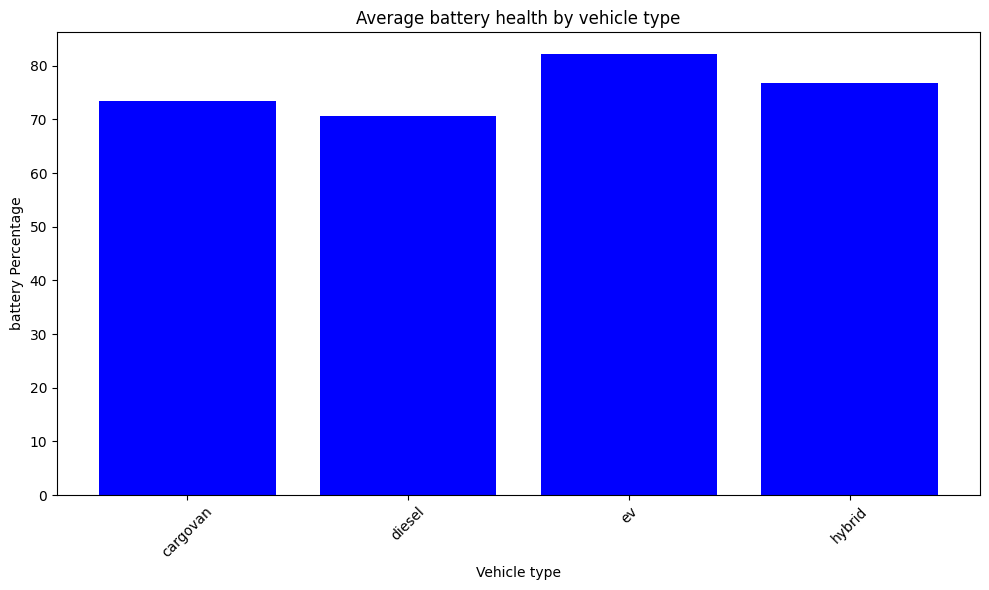

In [ ]:
bar_data = df_vehicles.groupby("vehicle_type")["battery_health_pct"].mean()

plt.figure(figsize=(10, 6))
plt.bar(bar_data.index, bar_data.values, color="blue")

plt.title("Average battery health by vehicle type")
plt.xlabel("Vehicle type")
plt.ylabel("battery Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

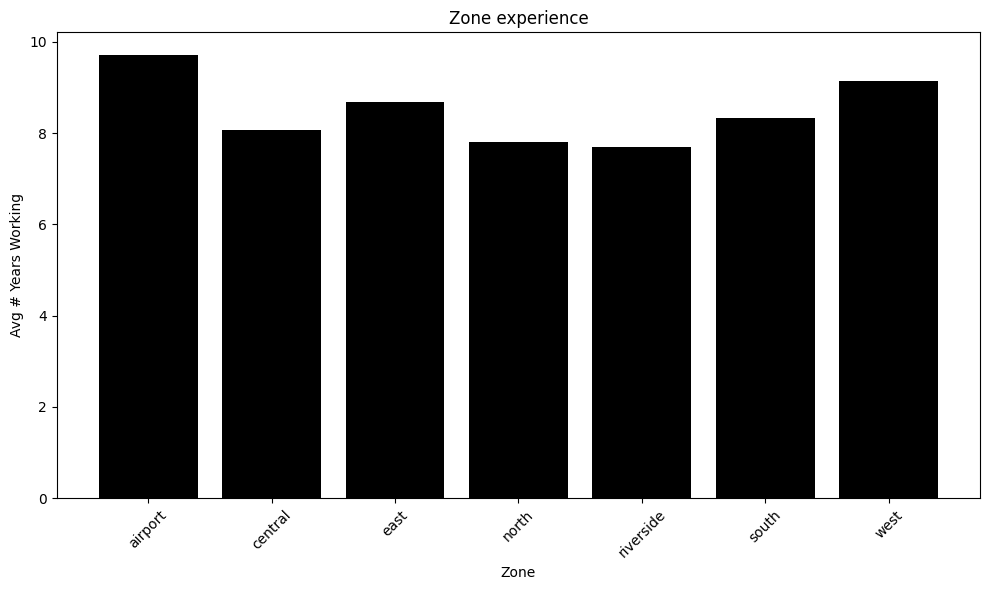

In [ ]:
bar_data = df_drivers.groupby("base_zone")["years_experience"].mean()

plt.figure(figsize=(10, 6))
plt.bar(bar_data.index, bar_data.values, color="black")

plt.title("Zone experience")
plt.xlabel("Zone")
plt.ylabel("Avg # Years Working")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# this is to export all the transformed datasets to prepare for R analytics and SQl


clean_drivers = df_drivers
clean_drivers.to_csv('clean_drivers.csv', index=False)
!cp clean_drivers.csv "/content/drive/My Drive/"

clean_hubs = df_hubs
clean_hubs.to_csv('clean_hubs.csv', index=False)
!cp clean_hubs.csv "/content/drive/My Drive/"

clean_incidents = df_incidents
clean_incidents.to_csv('clean_incidents.csv', index=False)
!cp clean_incidents.csv "/content/drive/My Drive/"

clean_orders = df_orders
clean_orders.to_csv('clean_orders.csv', index=False)
!cp clean_orders.csv "/content/drive/My Drive/"

clean_vehicles = df_vehicles
clean_vehicles.to_csv('clean_vehicles.csv', index=False)
!cp clean_vehicles.csv "/content/drive/My Drive/"

with open("order_app_event_histories.json", "w", encoding="utf-8") as f:
    json.dump(app_documents, f, indent=2, default=str)

!cp order_app_event_histories.json "/content/drive/My Drive/"

clean_complaints = df_complaints
clean_complaints.to_csv('clean_complaints.csv', index=False)
!cp clean_complaints.csv "/content/drive/My Drive/"

clean_customers = df_customers
clean_customers.to_csv('clean_customers.csv', index=False)
!cp clean_customers.csv "/content/drive/My Drive/"

clean_deliveries = df_deliveries
clean_deliveries.to_csv('clean_deliveries.csv', index=False)
!cp clean_deliveries.csv "/content/drive/My Drive/"

In [ ]:
clean_deliveries = df_deliveries
clean_deliveries.to_csv('clean_deliveries.csv', index=False)
!cp clean_deliveries.csv "/content/drive/My Drive/"